In [1]:
"""
Simulation for the Marginal Policy Effect (MPE) in a multi-stage, continuous-action setting.

We consider a Gaussian mean-shift (location shift) policy path:
    π_{t,ε}(a|s) = Normal(mean = m_t(s) + ε, var = v_t(s)),
so the stagewise score is available in closed form:
    H_t(s,a) := ∂_ε log π_{t,ε}(a|s)|_{ε=0} = (a - m_t(s)) / v_t(s).

Target (MPE):
    Θ = ∂_ε E[ Σ_{t=1}^T γ^{t-1} R_t ] |_{ε=0}.

For the location/mean-shift path, the generalized policy gradient theorem gives:
    Θ = E[ Σ_{t=1}^T γ^{t-1} ∂_a q_t^*(S_t, A_t) ],
and by integration-by-parts equivalently:
    Θ = E[ Σ_{t=1}^T κ_t(S_t,A_t) · q_t^*(S_t,A_t) ],
where κ_t := γ^{t-1} H_t.

Here we use the *return-to-go* (Monte Carlo) version of the one-step debiasing:
    G_t := Σ_{k=t}^T γ^{k-t} R_k  (discounted return-to-go from stage t)

and q_t^*(s,a) = E[ G_t | S_t=s, A_t=a ].

We implement four estimators:

  1) Direct:
       Σ_t γ^{t-1} ∂_a q̂_t(S_t, A_t)
       (pathwise / IBP form, using either analytic derivative for linear-in-action q nets
        or finite-differences in action for generic q nets)

  2) ASRW (one-step, return-to-go correction):
       Direct + Σ_t κ̂_t(S_t,A_t) · (G_t - q̂_t(S_t,A_t))

  3) ASRW (one-step, oracle κ*, return-to-go correction):
       Direct + Σ_t κ*_t(S_t,A_t) · (G_t - q̂_t(S_t,A_t))

  4) SRW (return-to-go, using κ̂ only):
       Σ_t κ̂_t(S_t,A_t) · G_t

-------------------------------------------------------------------------------
IMPORTANT CHANGE (relative to the earlier script):

We now *learn* κ̂_t via the variational characterization of the Riesz representer
("Riesz regression" / Auto-DML style), rather than by supervised regression on
the oracle pseudo-outcome κ*_t.

For the location-shift path, Example 3 gives the IBP identity:
    G_t(q) = γ^{t-1} E[ ∂_a q(S_t, A_t) ].

The (discounted) Riesz representer κ_t is the unique function (in L2) such that:
    G_t(q) = E[ κ_t(S_t,A_t) q(S_t,A_t) ]   for all square-integrable q.

Equivalently, κ_t is the minimizer of the quadratic variational objective:
    κ_t = argmin_g  E[ g(Z_t)^2 - 2 G_t(g) ],   Z_t := (S_t, A_t).

We estimate it by the sample analogue over a NN class K_t:
    κ̂_t ∈ argmin_{g∈K_t}  En[ g(Z_t)^2 - 2 γ^{t-1} ∂_a g(S_t, A_t) ].

To keep training stable and avoid second derivatives, we default to a
*linear-in-action* network for κ̂_t:
    g(s,a) = f(s) + a_scaled * h(s),
for which ∂_a g = h(s) / A_std is analytic.
"""


import time
import logging
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import KFold

from joblib import Parallel, delayed

import matplotlib.pyplot as plt


# =============================================================================
# Global config
# =============================================================================
T_DEFAULT = 2
GAMMA_DEFAULT = 0.99
N_DEFAULT = 5000
P_DEFAULT = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)


# =============================================================================
# Utilities
# =============================================================================
def set_all_seeds(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class Standardizer:
    """Columnwise standardizer for S_t and scalar standardizer for A_t per stage."""
    def __init__(self, eps: float = 1e-8):
        self.eps = eps
        self.S_mean = None
        self.S_std = None
        self.A_mean = None
        self.A_std = None

    def fit(self, S: np.ndarray, A: np.ndarray):
        S = np.asarray(S, dtype=float)
        A = np.asarray(A, dtype=float).reshape(-1, 1)
        self.S_mean = S.mean(axis=0, keepdims=True)
        self.S_std = np.maximum(S.std(axis=0, keepdims=True), self.eps)
        self.A_mean = float(A.mean())
        self.A_std = float(max(A.std(), self.eps))
        return self

    def transform_S(self, S: np.ndarray) -> np.ndarray:
        S = np.asarray(S, dtype=float)
        return (S - self.S_mean) / self.S_std

    def transform_A(self, A: np.ndarray) -> np.ndarray:
        A = np.asarray(A, dtype=float).reshape(-1, 1)
        return (A - self.A_mean) / self.A_std


def torch_predict(net: nn.Module, X: np.ndarray, batch_size: int = 8192) -> np.ndarray:
    """Predict net(X) on device in batches. X is numpy float32."""
    net = net.to(device)
    net.eval()
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    out = np.zeros(n, dtype=np.float32)

    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(n, start + batch_size)
            xb = torch.tensor(X[start:end], dtype=torch.float32, device=device)
            out[start:end] = net(xb).detach().cpu().numpy().flatten()
    return out.astype(float)


# =============================================================================
# 1) Data generation (full-history) + return-to-go
# =============================================================================
def generate_data_mpe(
    N: int,
    p: int = P_DEFAULT,
    T: int = T_DEFAULT,
    gamma: float = GAMMA_DEFAULT,
    delta: float = 0.1,
    sigma_x: float = 1.0,
    tau_const: float = 2.0,
    sigma_r: float = 1.0,
    eps_shift: float = 0.0,
    seed: Optional[int] = None,
) -> Dict:
    """
    Multi-stage DGP with continuous actions and Gaussian behavior policy.
    eps_shift applies a pure location shift to the action mean along the policy path.

    Full-history convention:
      S_t = (X_1,A_1,R_1, ..., X_{t-1},A_{t-1},R_{t-1}, X_t).

    We also compute the return-to-go (discounted from stage t):
      G_t = Σ_{k=t}^T γ^{k-t} R_k,
      with G_{T+1} = 0.
    """
    if seed is not None:
        np.random.seed(seed)

    def complex_var(eta):
        z = np.sign(eta) * np.sqrt(np.abs(eta))
        return 0.25 + (z + 0.1 * np.sign(z)) ** 2

    X = [None] * (T + 1)
    A = [None] * (T + 1)
    mA = [None] * (T + 1)
    varA = [None] * (T + 1)
    R = [None] * (T + 1)

    # Correlated Gaussian initial X_1
    idx = np.arange(p)
    Sigma = 0.5 ** np.abs(idx[:, None] - idx[None, :])
    X[1] = np.random.multivariate_normal(np.zeros(p), Sigma, size=N)

    hist_X_sum = X[1].copy()

    for t in range(1, T + 1):
        X_t = X[t]
        xbar = X_t.mean(axis=1, keepdims=True)

        hist_mean = hist_X_sum / float(t)
        hist_xbar = hist_mean.mean(axis=1, keepdims=True)

        a_prev = A[t - 1] if t > 1 else np.zeros((N, 1))
        eta = xbar + 0.3 * a_prev

        varA_t = complex_var(eta)  # (N,1)
        mA_t = 0.5 + 0.2 * xbar + 0.1 * hist_xbar

        A_t = mA_t + eps_shift + np.sqrt(varA_t) * np.random.randn(N, 1)

        mA[t] = mA_t
        varA[t] = varA_t
        A[t] = A_t

        # State transition
        if t < T:
            noise_x = sigma_x * np.random.randn(N, p)
            X_next = X_t + delta * A_t + 0.1 * hist_mean + noise_x
            X[t + 1] = X_next
            hist_X_sum = hist_X_sum + X_next

        # Reward
        mu_t = 1.0 + 0.5 * X_t.sum(axis=1, keepdims=True)
        eps_t = sigma_r * np.random.randn(N, 1)
        R_t = mu_t + tau_const * A_t + eps_t
        R[t] = R_t

    # Build full-history S_t
    S = [None] * (T + 1)
    for t in range(1, T + 1):
        parts = []
        for j in range(1, t):
            parts.extend([X[j], A[j], R[j]])
        parts.append(X[t])
        S[t] = np.hstack(parts)

    # Return-to-go G_t (discount from stage t)
    G = [None] * (T + 2)
    G[T + 1] = np.zeros(N, dtype=float)
    for t in range(T, 0, -1):
        G[t] = R[t].flatten() + gamma * G[t + 1]

    # Total discounted return from t=1
    Y = G[1].copy()

    return {
        "X": X,
        "A": A,
        "mA": mA,
        "varA": varA,
        "S": S,
        "R": R,
        "G": G,            # return-to-go list, indexed by t
        "Y": Y,            # same as G[1]
        "gamma": gamma,
        "T": T,
        "N": N,
        "p": p,
    }


def subset_data(data: Dict, idx: np.ndarray) -> Dict:
    """Return a data dict with rows subset to idx (for every t)."""
    T = data["T"]
    out = {"gamma": data["gamma"], "T": T, "N": len(idx), "p": data["p"]}
    for key in ["X", "A", "mA", "varA", "S", "R"]:
        out[key] = [None] * (T + 1)
        for t in range(1, T + 1):
            out[key][t] = data[key][t][idx].copy()
    # return-to-go
    out["G"] = [None] * (T + 2)
    out["G"][T + 1] = np.zeros(len(idx), dtype=float)
    for t in range(1, T + 1):
        out["G"][t] = data["G"][t][idx].copy()
    out["Y"] = data["Y"][idx].copy()
    return out


# =============================================================================
# 2) Oracle score H*, discounted score κ*
# =============================================================================
def oracle_score_H(data: Dict, var_floor: float = 1e-8) -> list:
    """
    Oracle score for Gaussian mean-shift path:
      H*_t = (A_t - m_t) / var_t
    """
    T = data["T"]
    H_list = [None] * (T + 1)
    for t in range(1, T + 1):
        A = data["A"][t].flatten()
        m = data["mA"][t].flatten()
        v = np.maximum(data["varA"][t].flatten(), var_floor)
        H_list[t] = (A - m) / v
    return H_list


def discounted_score_kappa_from_H(H_list: list, gamma: float) -> list:
    """κ_t = γ^{t-1} H_t."""
    T = len(H_list) - 1
    kappa = [None] * (T + 1)
    for t in range(1, T + 1):
        kappa[t] = (gamma ** (t - 1)) * np.asarray(H_list[t], dtype=float)
    return kappa


# =============================================================================
# 3) Q nets: generic MLP or linear-in-action (recommended)
# =============================================================================
class QNetMLP(nn.Module):
    """q(s,a) as generic MLP on concatenated input [a_scaled, s_scaled]."""
    def __init__(self, input_dim: int, hidden_dim: int = 128, n_layers: int = 2, activation: str = "silu"):
        super().__init__()
        Act = nn.SiLU if activation.lower() == "silu" else nn.ReLU
        layers = []
        d = input_dim
        for _ in range(n_layers):
            layers.append(nn.Linear(d, hidden_dim))
            layers.append(Act())
            d = hidden_dim
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class QNetLinearA(nn.Module):
    """
    q(s,a) = f(s) + a_scaled * g(s).
    Very stable for derivatives.
    """
    def __init__(self, s_dim: int, hidden_dim: int = 128, n_layers: int = 2, activation: str = "silu"):
        super().__init__()
        Act = nn.SiLU if activation.lower() == "silu" else nn.ReLU
        layers = []
        d = s_dim
        for _ in range(n_layers):
            layers.append(nn.Linear(d, hidden_dim))
            layers.append(Act())
            d = hidden_dim
        self.trunk = nn.Sequential(*layers)
        self.head_f = nn.Linear(hidden_dim, 1)
        self.head_g = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        a = x[:, [0]]     # a_scaled
        s = x[:, 1:]      # s_scaled
        h = self.trunk(s)
        f = self.head_f(h)
        g = self.head_g(h)
        return f + a * g

    def fg_from_s(self, s_scaled: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Return (f(s), g(s)) given s_scaled (tensor on device)."""
        h = self.trunk(s_scaled)
        f = self.head_f(h)
        g = self.head_g(h)
        return f, g


def build_q_features(S_t: np.ndarray, A_t: np.ndarray, scaler: Standardizer) -> np.ndarray:
    """Build [a_scaled, s_scaled]."""
    s_scaled = scaler.transform_S(S_t)
    a_scaled = scaler.transform_A(A_t)
    return np.hstack([a_scaled, s_scaled]).astype(np.float32)


def train_regressor_nn(
    model: nn.Module,
    X: np.ndarray,
    Y: np.ndarray,
    n_epochs: int = 250,
    lr: float = 5e-4,
    batch_size: int = 512,
    weight_decay: float = 1e-4,
    val_frac: float = 0.1,
    patience: int = 25,
    grad_clip: float = 5.0,
) -> nn.Module:
    """Regression trainer with early stopping (MSE)."""
    model.to(device)
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32).reshape(-1, 1)

    n = X.shape[0]
    n_val = int(val_frac * n)
    perm = np.random.permutation(n)
    val_idx = perm[:n_val] if n_val > 0 else np.array([], dtype=int)
    tr_idx = perm[n_val:] if n_val > 0 else perm

    X_tr, Y_tr = X[tr_idx], Y[tr_idx]
    X_val, Y_val = (X[val_idx], Y[val_idx]) if n_val > 0 else (None, None)

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    Yt = torch.tensor(Y_tr, dtype=torch.float32, device=device)
    ds = TensorDataset(Xt, Yt)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val = float("inf")
    no_imp = 0

    for _ in range(n_epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            pred = model(xb)
            loss = ((pred - yb) ** 2).mean()
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

        if X_val is not None:
            model.eval()
            with torch.no_grad():
                Xv = torch.tensor(X_val, dtype=torch.float32, device=device)
                Yv = torch.tensor(Y_val, dtype=torch.float32, device=device)
                pv = model(Xv)
                val_loss = ((pv - Yv) ** 2).mean().item()

            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


# =============================================================================
# 4) Q estimation: regress return-to-go G_t (no Bellman / no V_{t+1})
# =============================================================================
def fit_q_nets_return_to_go(
    data_tr: Dict,
    q_arch: str = "linear_a",     # "linear_a" or "mlp"
    hidden_dim: int = 128,
    n_layers: int = 2,
    activation: str = "silu",
    n_epochs: int = 250,
    lr: float = 5e-4,
    batch_size: int = 512,
    weight_decay: float = 1e-4,
) -> Tuple[list, list]:
    """
    Stagewise Monte-Carlo (return-to-go) regression:
      For each t, fit q_t(S_t, A_t) on target G_t.
    This avoids Bellman recursion and avoids V_{t+1} entirely.
    """
    T = data_tr["T"]

    scalers = [None] * (T + 1)
    q_nets = [None] * (T + 1)

    for t in range(1, T + 1):
        scalers[t] = Standardizer().fit(data_tr["S"][t], data_tr["A"][t])
        Xq = build_q_features(data_tr["S"][t], data_tr["A"][t], scalers[t])
        Y = data_tr["G"][t].flatten()

        if q_arch == "linear_a":
            net = QNetLinearA(s_dim=Xq.shape[1] - 1, hidden_dim=hidden_dim, n_layers=n_layers, activation=activation)
        elif q_arch == "mlp":
            net = QNetMLP(input_dim=Xq.shape[1], hidden_dim=hidden_dim, n_layers=n_layers, activation=activation)
        else:
            raise ValueError("q_arch must be 'linear_a' or 'mlp'.")

        q_nets[t] = train_regressor_nn(
            net, Xq, Y,
            n_epochs=n_epochs, lr=lr, batch_size=batch_size, weight_decay=weight_decay
        )

    return q_nets, scalers


def predict_q_hat(
    q_nets: list,
    scalers: list,
    data_te: Dict,
) -> list:
    """Predict q_hat[t] at the observed actions on the scoring fold."""
    T = data_te["T"]
    q_hat = [None] * (T + 1)
    for t in range(1, T + 1):
        Xq_obs = build_q_features(data_te["S"][t], data_te["A"][t], scalers[t])
        q_hat[t] = torch_predict(q_nets[t], Xq_obs)
    return q_hat


# =============================================================================
# 5) κ learning via variational (Riesz) regression for the location-shift functional
# =============================================================================
def _forward_and_d_dA(
    model: nn.Module,
    xb: torch.Tensor,
    a_std: float,
    create_graph: bool,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Return (pred, d_pred_dA) where A is the *original* action scale.
    xb is [a_scaled, s_scaled].
    """
    if isinstance(model, QNetLinearA):
        # pred = f(s) + a_scaled * g(s)
        pred = model(xb)
        s_scaled = xb[:, 1:]
        _, g = model.fg_from_s(s_scaled)
        d_pred_dA = (g / float(a_std)).squeeze(-1)
        return pred, d_pred_dA

    # Generic MLP: need autograd w.r.t. input
    xb_req = xb.detach().clone().requires_grad_(True)
    pred = model(xb_req)
    grad = torch.autograd.grad(
        outputs=pred.sum(),
        inputs=xb_req,
        create_graph=create_graph,
        retain_graph=create_graph,
    )[0]
    d_pred_dA = grad[:, 0] / float(a_std)
    return pred, d_pred_dA


def train_variational_riesz_kappa_nn(
    model: nn.Module,
    X: np.ndarray,
    gamma_pow: float,
    a_std: float,
    n_epochs: int = 250,
    lr: float = 5e-4,
    batch_size: int = 512,
    weight_decay: float = 1e-4,
    val_frac: float = 0.1,
    patience: int = 25,
    grad_clip: float = 5.0,
    grad_penalty: float = 0.0,
) -> nn.Module:
    """
    Variational / Riesz regression for the location-shift functional:
        L_t(f) = γ^{t-1} E[ ∂_a f(S_t, A_t) ].

    Estimate κ_t as the minimizer over the model class of:
        En[ κ(Z)^2 - 2 L_t(κ) ]
      = En[ κ(Z)^2 - 2 γ^{t-1} ∂_a κ(Z) ].

    Notes:
      • If model is QNetLinearA, ∂_a κ is analytic and training uses only first-order backprop.
      • If model is QNetMLP, computing gradients of ∂_a κ w.r.t parameters requires second
        derivatives (create_graph=True), which is slower.
      • grad_penalty optionally adds λ ||∂_a κ||^2 to stabilize training.
    """
    model.to(device)
    X = np.asarray(X, dtype=np.float32)

    n = X.shape[0]
    n_val = int(val_frac * n)
    perm = np.random.permutation(n)
    val_idx = perm[:n_val] if n_val > 0 else np.array([], dtype=int)
    tr_idx = perm[n_val:] if n_val > 0 else perm

    X_tr = X[tr_idx]
    X_val = X[val_idx] if n_val > 0 else None

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    ds = TensorDataset(Xt)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val = float("inf")
    no_imp = 0

    for _ in range(n_epochs):
        model.train()
        for (xb,) in loader:
            opt.zero_grad()

            pred, d_pred_dA = _forward_and_d_dA(
                model=model,
                xb=xb,
                a_std=a_std,
                create_graph=True,  # need grads through d_pred_dA if using MLP
            )

            # variational objective: E[ pred^2 - 2 gamma_pow * d_pred_dA ]
            loss = (pred.squeeze(-1) ** 2 - 2.0 * float(gamma_pow) * d_pred_dA).mean()

            if grad_penalty and grad_penalty > 0.0:
                loss = loss + float(grad_penalty) * (d_pred_dA ** 2).mean()

            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

        if X_val is not None:
            model.eval()
            # For validation we don't backprop; but we still may need autograd if MLP.
            Xv = torch.tensor(X_val, dtype=torch.float32, device=device)
            with torch.set_grad_enabled(not isinstance(model, QNetLinearA)):
                pv, dv = _forward_and_d_dA(
                    model=model,
                    xb=Xv,
                    a_std=a_std,
                    create_graph=False,
                )
                val_loss = (pv.squeeze(-1) ** 2 - 2.0 * float(gamma_pow) * dv).mean().item()
                if grad_penalty and grad_penalty > 0.0:
                    val_loss = float(val_loss + float(grad_penalty) * (dv ** 2).mean().item())

            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


@dataclass
class AutoDMLScoreModel:
    """
    Stores a learned discounted score approximator κ_hat_t(Z_t).
    """
    net: nn.Module
    scaler: Standardizer


def fit_kappa_models(
    data_tr: Dict,
    # Choose learning method:
    #   "variational": true variational/Riesz regression using IBP (no oracle κ*)
    #   "oracle_projection": old simulation proxy (project κ* onto NN class)
    kappa_fit_method: str = "variational",
    # Architecture for κ nets
    kappa_arch: str = "linear_a",   # "linear_a" (recommended) or "mlp"
    hidden_dim: int = 128,
    n_layers: int = 2,
    activation: str = "silu",
    n_epochs: int = 250,
    lr: float = 5e-4,
    batch_size: int = 512,
    weight_decay: float = 1e-4,
    random_state: int = 123,
    # Only used for oracle_projection
    var_floor: float = 1e-8,
    # Optional stabilizer for variational training
    grad_penalty: float = 0.0,
) -> list:
    """
    Learn κ_hat_t(Z_t) in a NN class.

    If kappa_fit_method == "variational":
        Use the variational characterization of the Riesz representer for the
        location-shift functional:
            κ_hat_t ∈ argmin_{g∈K_t} En[ g(Z_t)^2 - 2 γ^{t-1} ∂_a g(Z_t) ].

    If kappa_fit_method == "oracle_projection" (simulation-only baseline):
        Compute the oracle κ*_t = γ^{t-1} (A_t - mA_t) / varA_t and project it into the NN class
        by least squares (equivalently the quadratic-variational form).
    """
    T = data_tr["T"]
    gamma = data_tr["gamma"]

    models = [None] * (T + 1)

    for t in range(1, T + 1):
        # deterministic init per stage (and fold if random_state shifted externally)
        torch.manual_seed(random_state + 1000 * t)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(random_state + 1000 * t)

        scaler = Standardizer().fit(data_tr["S"][t], data_tr["A"][t])
        X = build_q_features(data_tr["S"][t], data_tr["A"][t], scaler)
        gamma_pow = gamma ** (t - 1)

        if kappa_arch == "linear_a":
            net = QNetLinearA(s_dim=X.shape[1] - 1, hidden_dim=hidden_dim, n_layers=n_layers, activation=activation)
        elif kappa_arch == "mlp":
            net = QNetMLP(input_dim=X.shape[1], hidden_dim=hidden_dim, n_layers=n_layers, activation=activation)
        else:
            raise ValueError("kappa_arch must be 'linear_a' or 'mlp'.")

        if kappa_fit_method == "variational":
            net = train_variational_riesz_kappa_nn(
                model=net,
                X=X,
                gamma_pow=gamma_pow,
                a_std=scaler.A_std,
                n_epochs=n_epochs,
                lr=lr,
                batch_size=batch_size,
                weight_decay=weight_decay,
                val_frac=0.1,
                patience=25,
                grad_clip=5.0,
                grad_penalty=grad_penalty,
            )
        elif kappa_fit_method == "oracle_projection":
            # Simulation-only proxy: regress oracle κ* on Z_t (same as old script)
            A = data_tr["A"][t].flatten()
            mA = data_tr["mA"][t].flatten()
            varA = np.maximum(data_tr["varA"][t].flatten(), var_floor)
            kappa_star = gamma_pow * (A - mA) / varA

            net = train_regressor_nn(
                model=net,
                X=X,
                Y=kappa_star,
                n_epochs=n_epochs,
                lr=lr,
                batch_size=batch_size,
                weight_decay=weight_decay,
                val_frac=0.1,
                patience=25,
                grad_clip=5.0,
            )
        else:
            raise ValueError("kappa_fit_method must be 'variational' or 'oracle_projection'.")

        models[t] = AutoDMLScoreModel(net=net, scaler=scaler)

    return models


def predict_kappa_hat_on_fold(data_te: Dict, kappa_models: list) -> list:
    """Predict κ_hat_t on the scoring fold."""
    T = data_te["T"]
    kappa_hat = [None] * (T + 1)
    for t in range(1, T + 1):
        mdl: AutoDMLScoreModel = kappa_models[t]
        X = build_q_features(data_te["S"][t], data_te["A"][t], mdl.scaler)
        kappa_hat[t] = torch_predict(mdl.net, X)
    return kappa_hat


# =============================================================================
# 6) Direct: pathwise/IBP derivative for mean-shift path
# =============================================================================
def direct_derivative_fd(
    q_net_t: nn.Module,
    scaler: Standardizer,
    S_t: np.ndarray,
    A_t: np.ndarray,
    varA_t: np.ndarray,
    gamma_pow: float,
    fd_c: float = 0.05,
    h_min: float = 1e-3,
    h_max: float = 0.5,
) -> np.ndarray:
    """
    Central finite difference in action units:
      dq/da ≈ (q(a+h)-q(a-h))/(2h), step h_i proportional to sqrt(varA_i).
    """
    S_t = np.asarray(S_t, dtype=float)
    A = np.asarray(A_t, dtype=float).reshape(-1, 1)
    var = np.asarray(varA_t, dtype=float).reshape(-1, 1)

    h = fd_c * np.sqrt(np.maximum(var, 1e-12))
    h = np.clip(h, h_min, h_max)

    A_plus = A + h
    A_minus = A - h

    X_plus = build_q_features(S_t, A_plus, scaler)
    X_minus = build_q_features(S_t, A_minus, scaler)

    q_plus = torch_predict(q_net_t, X_plus)
    q_minus = torch_predict(q_net_t, X_minus)

    deriv = (q_plus - q_minus) / (2.0 * h.flatten())
    return gamma_pow * deriv


def direct_derivative_linear_a(
    q_net_t: QNetLinearA,
    scaler: Standardizer,
    S_t: np.ndarray,
    gamma_pow: float,
    batch_size: int = 8192,
) -> np.ndarray:
    """
    For q(s,a)=f(s)+a_scaled*g(s):
      dq/da = g(s)/A_std.
    Independent of action; uses only s.
    """
    q_net_t = q_net_t.to(device)
    q_net_t.eval()

    s_scaled = scaler.transform_S(S_t).astype(np.float32)
    n = s_scaled.shape[0]
    out = np.zeros(n, dtype=np.float32)

    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(n, start + batch_size)
            ss = torch.tensor(s_scaled[start:end], dtype=torch.float32, device=device)
            _, g = q_net_t.fg_from_s(ss)
            dq_da = (g / scaler.A_std).detach().cpu().numpy().flatten()
            out[start:end] = dq_da.astype(np.float32)

    return (gamma_pow * out).astype(float)


# =============================================================================
# 7) Cross-fitted estimation: Direct / ASRW / ASRW-oracleκ / SRW
# =============================================================================
@dataclass
class CrossFitResult:
    theta_direct: float
    theta_asrw: float
    theta_asrw_oraclek: float
    theta_srw: float
    contrib_direct: np.ndarray
    contrib_asrw: np.ndarray
    contrib_asrw_oraclek: np.ndarray
    contrib_srw: np.ndarray
    fold_id: np.ndarray
    fold_means: Dict[str, np.ndarray]   # keys: direct, asrw, asrw_oraclek, srw
    fold_weights: np.ndarray


def estimate_mpe_crossfit(
    data: Dict,
    n_splits_cf: int = 5,
    # q learning (return-to-go regression)
    q_arch: str = "linear_a",      # "linear_a" (recommended) or "mlp"
    hidden_dim_q: int = 128,
    n_layers_q: int = 2,
    activation_q: str = "silu",
    n_epochs_q: int = 250,
    lr_q: float = 5e-4,
    batch_size_q: int = 512,
    weight_decay_q: float = 1e-4,
    # Direct mode
    direct_mode: str = "linear_a",  # "linear_a" (if q_arch=linear_a) or "fd"
    fd_c: float = 0.05,
    # κ learning
    kappa_fit_method: str = "variational",  # "variational" (default) or "oracle_projection"
    kappa_arch: str = "linear_a",           # "linear_a" strongly recommended for variational
    hidden_dim_kappa: int = 128,
    n_layers_kappa: int = 2,
    activation_kappa: str = "silu",
    n_epochs_kappa: int = 250,
    lr_kappa: float = 5e-4,
    batch_size_kappa: int = 512,
    weight_decay_kappa: float = 1e-4,
    random_state_kappa: int = 123,
    grad_penalty_kappa: float = 0.0,
) -> CrossFitResult:
    N = data["N"]
    T = data["T"]
    gamma = data["gamma"]

    idx = np.arange(N)
    kf = KFold(n_splits=n_splits_cf, shuffle=True, random_state=123)

    contrib_direct_all = np.zeros(N)
    contrib_asrw_all = np.zeros(N)
    contrib_asrw_oraclek_all = np.zeros(N)
    contrib_srw_all = np.zeros(N)
    fold_id_of_obs = -np.ones(N, dtype=int)

    fold_means_direct = []
    fold_means_asrw = []
    fold_means_asrw_oraclek = []
    fold_means_srw = []
    fold_weights = []

    for fold_id, (tr_idx, te_idx) in enumerate(kf.split(idx), start=0):
        d_tr = subset_data(data, tr_idx)
        d_te = subset_data(data, te_idx)
        fold_id_of_obs[te_idx] = fold_id
        fold_weights.append(len(te_idx) / N)

        # Fit q on training fold (return-to-go regression)
        q_nets, scalers = fit_q_nets_return_to_go(
            d_tr,
            q_arch=q_arch,
            hidden_dim=hidden_dim_q,
            n_layers=n_layers_q,
            activation=activation_q,
            n_epochs=n_epochs_q,
            lr=lr_q,
            batch_size=batch_size_q,
            weight_decay=weight_decay_q,
        )

        # Predict q_hat on scoring fold
        q_hat_te = predict_q_hat(q_nets, scalers, d_te)

        # Learn κ models on training; predict on scoring
        kappa_models = fit_kappa_models(
            d_tr,
            kappa_fit_method=kappa_fit_method,
            kappa_arch=kappa_arch,
            hidden_dim=hidden_dim_kappa,
            n_layers=n_layers_kappa,
            activation=activation_kappa,
            n_epochs=n_epochs_kappa,
            lr=lr_kappa,
            batch_size=batch_size_kappa,
            weight_decay=weight_decay_kappa,
            random_state=random_state_kappa + 10 * fold_id,
            grad_penalty=grad_penalty_kappa,
        )
        kappa_hat_te = predict_kappa_hat_on_fold(d_te, kappa_models)

        # Oracle κ* benchmark
        H_star_te = oracle_score_H(d_te)
        kappa_star_te = discounted_score_kappa_from_H(H_star_te, gamma=gamma)

        # return-to-go residuals: e_t = G_t - q_hat_t
        rtg_resid_te = [None] * (T + 1)
        for t in range(1, T + 1):
            rtg_resid_te[t] = d_te["G"][t].flatten() - q_hat_te[t]

        # Contributions on scoring fold
        n_te = len(te_idx)
        c_dir = np.zeros(n_te)
        c_asrw_corr = np.zeros(n_te)
        c_asrw_oraclek_corr = np.zeros(n_te)
        c_srw = np.zeros(n_te)

        for t in range(1, T + 1):
            gpow = gamma ** (t - 1)

            # Direct: pathwise / IBP derivative
            if direct_mode == "linear_a":
                if not isinstance(q_nets[t], QNetLinearA):
                    raise ValueError("direct_mode='linear_a' requires q_arch='linear_a'.")
                c_dir += direct_derivative_linear_a(
                    q_net_t=q_nets[t],
                    scaler=scalers[t],
                    S_t=d_te["S"][t],
                    gamma_pow=gpow,
                )
            elif direct_mode == "fd":
                c_dir += direct_derivative_fd(
                    q_net_t=q_nets[t],
                    scaler=scalers[t],
                    S_t=d_te["S"][t],
                    A_t=d_te["A"][t],
                    varA_t=d_te["varA"][t],
                    gamma_pow=gpow,
                    fd_c=fd_c,
                )
            else:
                raise ValueError("direct_mode must be 'linear_a' or 'fd'")

            # ONE-STEP correction using return-to-go residual (no TD / no V_{t+1})
            c_asrw_corr += kappa_hat_te[t] * rtg_resid_te[t]
            c_asrw_oraclek_corr += kappa_star_te[t] * rtg_resid_te[t]

            # SRW (return-to-go) benchmark
            c_srw += kappa_hat_te[t] * d_te["G"][t].flatten()

        c_asrw = c_dir + c_asrw_corr
        c_asrw_oraclek = c_dir + c_asrw_oraclek_corr

        # assign back
        contrib_direct_all[te_idx] = c_dir
        contrib_asrw_all[te_idx] = c_asrw
        contrib_asrw_oraclek_all[te_idx] = c_asrw_oraclek
        contrib_srw_all[te_idx] = c_srw

        # fold means (for fold-cluster SE)
        fold_means_direct.append(c_dir.mean())
        fold_means_asrw.append(c_asrw.mean())
        fold_means_asrw_oraclek.append(c_asrw_oraclek.mean())
        fold_means_srw.append(c_srw.mean())

    fold_weights = np.asarray(fold_weights, dtype=float)
    fold_means = {
        "direct": np.asarray(fold_means_direct, dtype=float),
        "asrw": np.asarray(fold_means_asrw, dtype=float),
        "asrw_oraclek": np.asarray(fold_means_asrw_oraclek, dtype=float),
        "srw": np.asarray(fold_means_srw, dtype=float),
    }

    theta_direct = float(contrib_direct_all.mean())
    theta_asrw = float(contrib_asrw_all.mean())
    theta_asrw_oraclek = float(contrib_asrw_oraclek_all.mean())
    theta_srw = float(contrib_srw_all.mean())

    return CrossFitResult(
        theta_direct=theta_direct,
        theta_asrw=theta_asrw,
        theta_asrw_oraclek=theta_asrw_oraclek,
        theta_srw=theta_srw,
        contrib_direct=contrib_direct_all,
        contrib_asrw=contrib_asrw_all,
        contrib_asrw_oraclek=contrib_asrw_oraclek_all,
        contrib_srw=contrib_srw_all,
        fold_id=fold_id_of_obs,
        fold_means=fold_means,
        fold_weights=fold_weights,
    )


# =============================================================================
# 8) Oracle target Theta via finite differences (CRN) along mean-shift path
# =============================================================================
def estimate_oracle_mpe_fd(
    eps: float = 0.05,
    N_mc: int = 200_000,
    p: int = P_DEFAULT,
    T: int = T_DEFAULT,
    gamma: float = GAMMA_DEFAULT,
    seed: int = 777,
    crn: bool = True,
) -> float:
    """Oracle via finite differences on the policy path using ±eps mean shifts."""
    seed_plus = seed
    seed_minus = seed if crn else seed + 1

    data_plus = generate_data_mpe(N=N_mc, p=p, T=T, gamma=gamma, eps_shift=eps, seed=seed_plus)
    data_minus = generate_data_mpe(N=N_mc, p=p, T=T, gamma=gamma, eps_shift=-eps, seed=seed_minus)

    J_plus = data_plus["Y"].mean()
    J_minus = data_minus["Y"].mean()
    return float((J_plus - J_minus) / (2.0 * eps))


# =============================================================================
# 9) Metrics: bias/RMSE + SE + coverage
# =============================================================================
def bias_rmse(ests: np.ndarray, oracle: float) -> Tuple[float, float]:
    ests = np.asarray(ests, dtype=float)
    bias = float(ests.mean() - oracle)
    rmse = float(np.sqrt(((ests - oracle) ** 2).mean()))
    return bias, rmse


def se_iid_from_contrib(contrib: np.ndarray) -> float:
    """Naive iid SE."""
    contrib = np.asarray(contrib, dtype=float)
    n = contrib.shape[0]
    return float(contrib.std(ddof=1) / np.sqrt(n))


def se_fold_cluster(theta_hat: float, fold_means: np.ndarray, fold_weights: np.ndarray) -> float:
    """
    Fold-cluster SE: clusters = scoring folds (shared nuisance fits).
    Weighted cluster-robust variance:
      Var = (K/(K-1)) * sum_k w_k^2 (theta_k - theta)^2
    where theta = sum_k w_k theta_k.
    """
    fold_means = np.asarray(fold_means, dtype=float)
    fold_weights = np.asarray(fold_weights, dtype=float)
    K = len(fold_means)
    if K <= 1:
        return float("nan")
    var = (K / (K - 1)) * np.sum((fold_weights ** 2) * (fold_means - theta_hat) ** 2)
    return float(np.sqrt(max(var, 0.0)))


def coverage_wald(thetas: np.ndarray, ses: np.ndarray, oracle: float, alpha: float = 0.05) -> float:
    z = 1.959963984540054
    lower = thetas - z * ses
    upper = thetas + z * ses
    return float(((oracle >= lower) & (oracle <= upper)).mean())


def _fd_bins(x: np.ndarray, min_bins: int = 12, max_bins: int = 40) -> int:
    """Freedman–Diaconis rule with caps; falls back to sqrt(n) if IQR=0."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n <= 1:
        return min_bins
    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25
    if iqr <= 1e-12:
        return int(np.clip(np.sqrt(n), min_bins, max_bins))
    bw = 2.0 * iqr / (n ** (1/3))
    if bw <= 1e-12:
        return int(np.clip(np.sqrt(n), min_bins, max_bins))
    nb = int(np.ceil((x.max() - x.min()) / bw))
    return int(np.clip(nb, min_bins, max_bins))


def plot_histograms(
    ests_dict: Dict[str, np.ndarray],
    oracle_theta: float,
    sharex: bool = True,
    trim: float = 0.02,
    density: bool = True,
    rug: bool = False,
):
    names = list(ests_dict.keys())
    K = len(names)

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"][:K]

    all_vals = np.concatenate([np.asarray(v, dtype=float) for v in ests_dict.values()])
    all_vals = all_vals[np.isfinite(all_vals)]
    if all_vals.size == 0:
        return

    lo = np.quantile(all_vals, trim)
    hi = np.quantile(all_vals, 1 - trim)
    pad = 0.05 * (hi - lo + 1e-8)
    x_min, x_max = lo - pad, hi + pad

    fig, axes = plt.subplots(1, K, figsize=(4.2 * K, 3.6), sharey=density, sharex=sharex)
    if K == 1:
        axes = [axes]

    for ax, name, color in zip(axes, names, colors):
        vals = np.asarray(ests_dict[name], dtype=float)
        vals = vals[np.isfinite(vals)]

        nbins = _fd_bins(vals)
        ax.hist(
            vals,
            bins=nbins,
            density=density,
            alpha=0.88,
            color=color,
            edgecolor="white",
            linewidth=0.6,
        )

        ax.axvline(oracle_theta, color="black", linestyle="--", linewidth=1.6, label="Oracle")
        ax.axvline(vals.mean(), color="gray", linestyle="-", linewidth=1.6, label="Mean")

        if rug and vals.size <= 300:
            y0 = ax.get_ylim()[0]
            yr = ax.get_ylim()[1] - ax.get_ylim()[0]
            ax.plot(vals, np.full_like(vals, y0 + 0.02 * yr), "|", color="black", markersize=8, alpha=0.35)

        ax.set_title(name, fontsize=11)
        ax.set_xlabel("Estimate")
        ax.grid(alpha=0.25, linestyle=":")
        if sharex:
            ax.set_xlim([x_min, x_max])

    axes[0].legend(fontsize=9, frameon=True)
    axes[0].set_ylabel("Density" if density else "Frequency")
    plt.tight_layout()
    plt.show()


# =============================================================================
# 10) Replication + simulation wrapper
# =============================================================================
def run_replication(
    seed: int,
    N: int = N_DEFAULT,
    p: int = P_DEFAULT,
    T: int = T_DEFAULT,
    gamma: float = GAMMA_DEFAULT,
    # crossfit
    n_splits_cf: int = 5,
    # q training
    q_arch: str = "linear_a",
    hidden_dim_q: int = 128,
    n_layers_q: int = 2,
    n_epochs_q: int = 250,
    # Direct
    direct_mode: str = "linear_a",
    fd_c: float = 0.05,
    # κ training
    kappa_fit_method: str = "variational",
    kappa_arch: str = "linear_a",
    hidden_dim_kappa: int = 128,
    n_layers_kappa: int = 2,
    n_epochs_kappa: int = 250,
    grad_penalty_kappa: float = 0.0,
    # SE choice
    se_method: str = "fold_cluster", # "fold_cluster" or "iid"
) -> Dict:
    set_all_seeds(seed)
    data = generate_data_mpe(N=N, p=p, T=T, gamma=gamma, eps_shift=0.0, seed=seed)

    cf = estimate_mpe_crossfit(
        data,
        n_splits_cf=n_splits_cf,
        q_arch=q_arch,
        hidden_dim_q=hidden_dim_q,
        n_layers_q=n_layers_q,
        n_epochs_q=n_epochs_q,
        direct_mode=direct_mode,
        fd_c=fd_c,
        kappa_fit_method=kappa_fit_method,
        kappa_arch=kappa_arch,
        hidden_dim_kappa=hidden_dim_kappa,
        n_layers_kappa=n_layers_kappa,
        n_epochs_kappa=n_epochs_kappa,
        grad_penalty_kappa=grad_penalty_kappa,
    )

    # SEs
    if se_method == "iid":
        se_direct = se_iid_from_contrib(cf.contrib_direct)
        se_asrw = se_iid_from_contrib(cf.contrib_asrw)
        se_asrw_oraclek = se_iid_from_contrib(cf.contrib_asrw_oraclek)
        se_srw = se_iid_from_contrib(cf.contrib_srw)
    elif se_method == "fold_cluster":
        se_direct = se_fold_cluster(cf.theta_direct, cf.fold_means["direct"], cf.fold_weights)
        se_asrw = se_fold_cluster(cf.theta_asrw, cf.fold_means["asrw"], cf.fold_weights)
        se_asrw_oraclek = se_fold_cluster(cf.theta_asrw_oraclek, cf.fold_means["asrw_oraclek"], cf.fold_weights)
        se_srw = se_fold_cluster(cf.theta_srw, cf.fold_means["srw"], cf.fold_weights)
    else:
        raise ValueError("se_method must be 'fold_cluster' or 'iid'")

    return {
        "theta_direct": cf.theta_direct,
        "theta_asrw": cf.theta_asrw,
        "theta_asrw_oraclek": cf.theta_asrw_oraclek,
        "theta_srw": cf.theta_srw,
        "se_direct": se_direct,
        "se_asrw": se_asrw,
        "se_asrw_oraclek": se_asrw_oraclek,
        "se_srw": se_srw,
    }


def run_simulation(
    R: int = 100,
    N: int = N_DEFAULT,
    p: int = P_DEFAULT,
    T: int = T_DEFAULT,
    gamma: float = GAMMA_DEFAULT,
    # oracle target
    eps_oracle: float = 0.05,
    N_mc_oracle: int = 200_000,
    # crossfit + learners
    n_splits_cf: int = 5,
    q_arch: str = "linear_a",
    hidden_dim_q: int = 128,
    n_layers_q: int = 2,
    n_epochs_q: int = 250,
    # Direct
    direct_mode: str = "linear_a",
    fd_c: float = 0.05,
    # κ learner
    kappa_fit_method: str = "variational",
    kappa_arch: str = "linear_a",
    hidden_dim_kappa: int = 128,
    n_layers_kappa: int = 2,
    n_epochs_kappa: int = 250,
    grad_penalty_kappa: float = 0.0,
    # SE
    se_method: str = "fold_cluster",
    # misc
    verbose: bool = True,
    make_plots: bool = True,
    # parallelism over replications
    n_jobs: int = -1,  # -1 = use all cores, 1 = serial
) -> Dict:
    t0 = time.time()

    if verbose:
        logger.info("Estimating oracle MPE target (FD with CRN)...")
    theta_oracle = estimate_oracle_mpe_fd(
        eps=eps_oracle, N_mc=N_mc_oracle, p=p, T=T, gamma=gamma, seed=999, crn=True
    )
    if verbose:
        logger.info(f"Oracle MPE ≈ {theta_oracle:.4f}")

    # Parallelize replications over CPUs
    if n_jobs == 1:
        results = [
            run_replication(
                seed=r,
                N=N, p=p, T=T, gamma=gamma,
                n_splits_cf=n_splits_cf,
                q_arch=q_arch,
                hidden_dim_q=hidden_dim_q,
                n_layers_q=n_layers_q,
                n_epochs_q=n_epochs_q,
                direct_mode=direct_mode,
                fd_c=fd_c,
                kappa_fit_method=kappa_fit_method,
                kappa_arch=kappa_arch,
                hidden_dim_kappa=hidden_dim_kappa,
                n_layers_kappa=n_layers_kappa,
                n_epochs_kappa=n_epochs_kappa,
                grad_penalty_kappa=grad_penalty_kappa,
                se_method=se_method,
            )
            for r in range(R)
        ]
    else:
        # Use threading backend to avoid pickling issues with torch models
        results = Parallel(n_jobs=n_jobs, backend='threading')(
            delayed(run_replication)(
                seed=r,
                N=N, p=p, T=T, gamma=gamma,
                n_splits_cf=n_splits_cf,
                q_arch=q_arch,
                hidden_dim_q=hidden_dim_q,
                n_layers_q=n_layers_q,
                n_epochs_q=n_epochs_q,
                direct_mode=direct_mode,
                fd_c=fd_c,
                kappa_fit_method=kappa_fit_method,
                kappa_arch=kappa_arch,
                hidden_dim_kappa=hidden_dim_kappa,
                n_layers_kappa=n_layers_kappa,
                n_epochs_kappa=n_epochs_kappa,
                grad_penalty_kappa=grad_penalty_kappa,
                se_method=se_method,
            )
            for r in range(R)
        )

    theta_direct = np.array([x["theta_direct"] for x in results])
    theta_asrw = np.array([x["theta_asrw"] for x in results])
    theta_asrw_oraclek = np.array([x["theta_asrw_oraclek"] for x in results])
    theta_srw = np.array([x["theta_srw"] for x in results])

    se_direct = np.array([x["se_direct"] for x in results])
    se_asrw = np.array([x["se_asrw"] for x in results])
    se_asrw_oraclek = np.array([x["se_asrw_oraclek"] for x in results])
    se_srw = np.array([x["se_srw"] for x in results])

    b_direct, rmse_direct = bias_rmse(theta_direct, theta_oracle)
    b_asrw, rmse_asrw = bias_rmse(theta_asrw, theta_oracle)
    b_asrw_oraclek, rmse_asrw_oraclek = bias_rmse(theta_asrw_oraclek, theta_oracle)
    b_srw, rmse_srw = bias_rmse(theta_srw, theta_oracle)

    cov_direct = coverage_wald(theta_direct, se_direct, theta_oracle)
    cov_asrw = coverage_wald(theta_asrw, se_asrw, theta_oracle)
    cov_asrw_oraclek = coverage_wald(theta_asrw_oraclek, se_asrw_oraclek, theta_oracle)
    cov_srw = coverage_wald(theta_srw, se_srw, theta_oracle)

    elapsed = time.time() - t0

    if verbose:
        print(f"\nEstimator performance (R={R}, N={N}, T={T}, p={p})")
        print(f"Oracle MPE: {theta_oracle:.4f}")
        print(f"SE method: {se_method}")
        print(f"κ learner: {kappa_fit_method} (arch={kappa_arch}, grad_penalty={grad_penalty_kappa})\n")

        rows = [
            ("Direct", theta_direct.mean(), b_direct, rmse_direct, cov_direct),
            ("ASRW", theta_asrw.mean(), b_asrw, rmse_asrw, cov_asrw),
            ("ASRW (oracle κ)", theta_asrw_oraclek.mean(), b_asrw_oraclek, rmse_asrw_oraclek, cov_asrw_oraclek),
            ("SRW", theta_srw.mean(), b_srw, rmse_srw, cov_srw),
        ]

        name_w = max(len(r[0]) for r in rows) + 2
        header = f"{'Estimator':<{name_w}}{'Mean':>10}{'Bias':>10}{'RMSE':>10}{'Coverage':>10}"
        print(header)
        print("-" * len(header))
        for name, mean, bias, rmse, cov in rows:
            print(f"{name:<{name_w}}{mean:>10.4f}{bias:>10.4f}{rmse:>10.4f}{cov:>10.3f}")

        print(f"\nTotal time: {elapsed:.1f} seconds")

        print("\nSE sanity check (empirical SD vs mean reported SE):")
        print(f"  Direct: empSD={theta_direct.std(ddof=1):.4f}, meanSE={se_direct.mean():.4f}")
        print(f"  ASRW:   empSD={theta_asrw.std(ddof=1):.4f}, meanSE={se_asrw.mean():.4f}")
        print(f"  SRW:    empSD={theta_srw.std(ddof=1):.4f}, meanSE={se_srw.mean():.4f}")

    if make_plots:
        ests_dict = {
            "Direct": theta_direct,
            "ASRW": theta_asrw,
            "ASRW (oracle κ)": theta_asrw_oraclek,
            "SRW": theta_srw,
        }
        plot_histograms(ests_dict, theta_oracle)

    return {
        "theta_oracle": theta_oracle,
        "theta_direct": theta_direct,
        "theta_asrw": theta_asrw,
        "theta_asrw_oraclek": theta_asrw_oraclek,
        "theta_srw": theta_srw,
        "se_direct": se_direct,
        "se_asrw": se_asrw,
        "se_asrw_oraclek": se_asrw_oraclek,
        "se_srw": se_srw,
        "bias_direct": b_direct,
        "rmse_direct": rmse_direct,
        "cov_direct": cov_direct,
        "bias_asrw": b_asrw,
        "rmse_asrw": rmse_asrw,
        "cov_asrw": cov_asrw,
        "bias_asrw_oraclek": b_asrw_oraclek,
        "rmse_asrw_oraclek": rmse_asrw_oraclek,
        "cov_asrw_oraclek": cov_asrw_oraclek,
        "bias_srw": b_srw,
        "rmse_srw": rmse_srw,
        "cov_srw": cov_srw,
    }




2026-02-01 12:33:23,598 - INFO - Estimating oracle MPE target (FD with CRN)...
2026-02-01 12:33:24,502 - INFO - Oracle MPE ≈ 12.9308



Estimator performance (R=100, N=5000, T=5, p=5)
Oracle MPE: 12.9308
SE method: fold_cluster
κ learner: variational (arch=linear_a, grad_penalty=0.0)

Estimator              Mean      Bias      RMSE  Coverage
---------------------------------------------------------
Direct              12.4977   -0.4332    0.4831     0.160
ASRW                12.8934   -0.0375    0.2130     0.870
ASRW (oracle κ)     12.9221   -0.0088    0.2073     0.910
SRW                 13.5339    0.6031    0.7403     0.830

Total time: 30624.4 seconds

SE sanity check (empirical SD vs mean reported SE):
  Direct: empSD=0.2149, meanSE=0.1126
  ASRW:   empSD=0.2108, meanSE=0.2077
  SRW:    empSD=0.4315, meanSE=0.6095


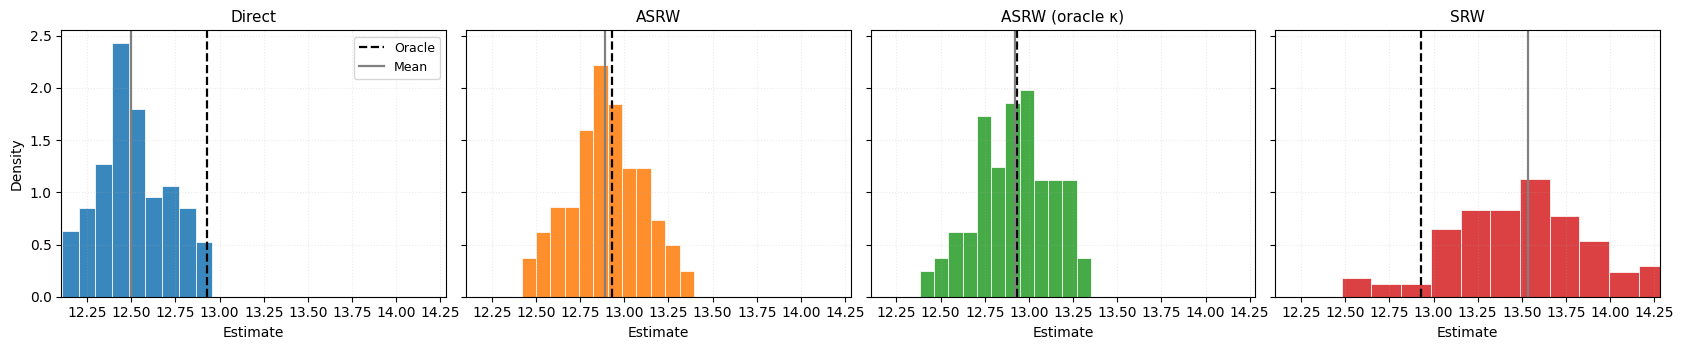

In [2]:
    out = run_simulation(
        R=100,
        N=5000,
        p=5,
        T=5,
        gamma=0.99,
        n_jobs=-1,
        n_splits_cf=5,
        q_arch="linear_a",
        direct_mode="linear_a",
        kappa_fit_method="variational",
        kappa_arch="linear_a",
        grad_penalty_kappa=0.0,
        n_epochs_q=150,
        n_epochs_kappa=150,
        make_plots=True,
        verbose=True,
    )

2026-02-01 21:03:48,270 - INFO - Estimating oracle MPE target (FD with CRN)...
2026-02-01 21:03:49,114 - INFO - Oracle MPE ≈ 15.5509



Estimator performance (R=100, N=5000, T=5, p=10)
Oracle MPE: 15.5509
SE method: fold_cluster
κ learner: variational (arch=linear_a, grad_penalty=0.0)

Estimator              Mean      Bias      RMSE  Coverage
---------------------------------------------------------
Direct              14.7312   -0.8198    0.8836     0.070
ASRW                15.4247   -0.1262    0.2982     0.890
ASRW (oracle κ)     15.5513    0.0004    0.2507     0.940
SRW                 16.5106    0.9597    1.0863     0.860

Total time: 25725.0 seconds

SE sanity check (empirical SD vs mean reported SE):
  Direct: empSD=0.3313, meanSE=0.1712
  ASRW:   empSD=0.2715, meanSE=0.2654
  SRW:    empSD=0.5116, meanSE=0.8455


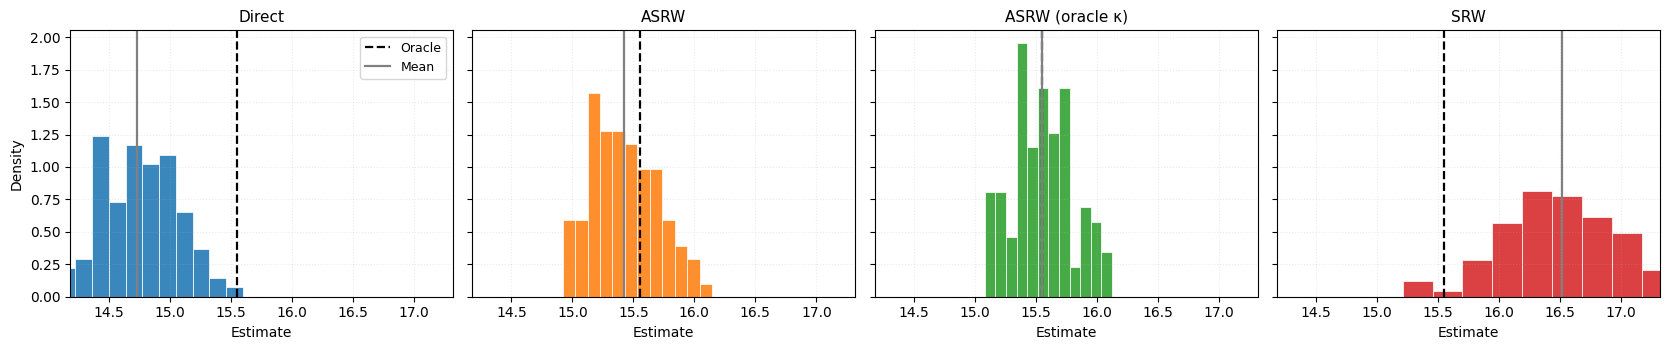

In [3]:
    out = run_simulation(
        R=100,
        N=5000,
        p=10,
        T=5,
        gamma=0.99,
        n_jobs=-1,
        n_splits_cf=5,
        q_arch="linear_a",
        direct_mode="linear_a",
        kappa_fit_method="variational",
        kappa_arch="linear_a",
        grad_penalty_kappa=0.0,
        n_epochs_q=150,
        n_epochs_kappa=150,
        make_plots=True,
        verbose=True,
    )

2026-02-02 04:12:33,532 - INFO - Estimating oracle MPE target (FD with CRN)...
2026-02-02 04:12:34,076 - INFO - Oracle MPE ≈ 12.9308



Estimator performance (R=100, N=20000, T=5, p=5)
Oracle MPE: 12.9308
SE method: fold_cluster
κ learner: variational (arch=linear_a, grad_penalty=0.0)

Estimator              Mean      Bias      RMSE  Coverage
---------------------------------------------------------
Direct              12.7948   -0.1361    0.1782     0.450
ASRW                12.9299   -0.0010    0.1100     0.860
ASRW (oracle κ)     12.9265   -0.0043    0.1122     0.870
SRW                 13.1902    0.2593    0.3255     0.840

Total time: 99091.6 seconds

SE sanity check (empirical SD vs mean reported SE):
  Direct: empSD=0.1156, meanSE=0.0626
  ASRW:   empSD=0.1106, meanSE=0.1051
  SRW:    empSD=0.1976, meanSE=0.2958


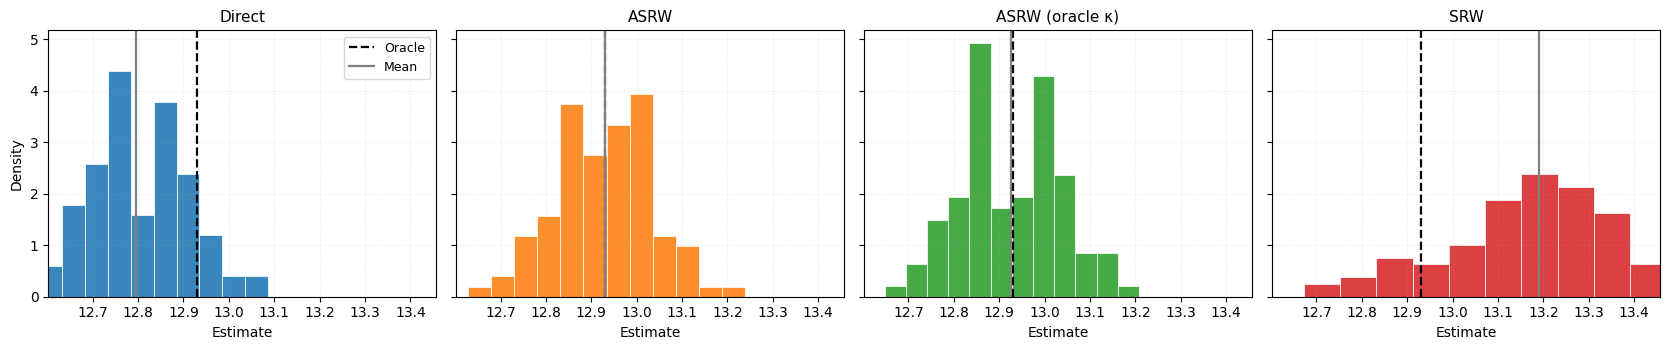

In [4]:
    out = run_simulation(
        R=100,
        N=20000,
        p=5,
        T=5,
        gamma=0.99,
        n_jobs=-1,
        n_splits_cf=5,
        q_arch="linear_a",
        direct_mode="linear_a",
        kappa_fit_method="variational",
        kappa_arch="linear_a",
        grad_penalty_kappa=0.0,
        n_epochs_q=150,
        n_epochs_kappa=150,
        make_plots=True,
        verbose=True,
    )

2026-02-03 07:44:05,346 - INFO - Estimating oracle MPE target (FD with CRN)...
2026-02-03 07:44:06,226 - INFO - Oracle MPE ≈ 15.5509



Estimator performance (R=100, N=20000, T=5, p=10)
Oracle MPE: 15.5509
SE method: fold_cluster
κ learner: variational (arch=linear_a, grad_penalty=0.0)

Estimator              Mean      Bias      RMSE  Coverage
---------------------------------------------------------
Direct              15.3311   -0.2198    0.2683     0.240
ASRW                15.5552    0.0042    0.1335     0.880
ASRW (oracle κ)     15.5599    0.0089    0.1384     0.840
SRW                 15.9687    0.4178    0.4840     0.750

Total time: 81717.3 seconds

SE sanity check (empirical SD vs mean reported SE):
  Direct: empSD=0.1546, meanSE=0.0789
  ASRW:   empSD=0.1341, meanSE=0.1337
  SRW:    empSD=0.2456, meanSE=0.3755


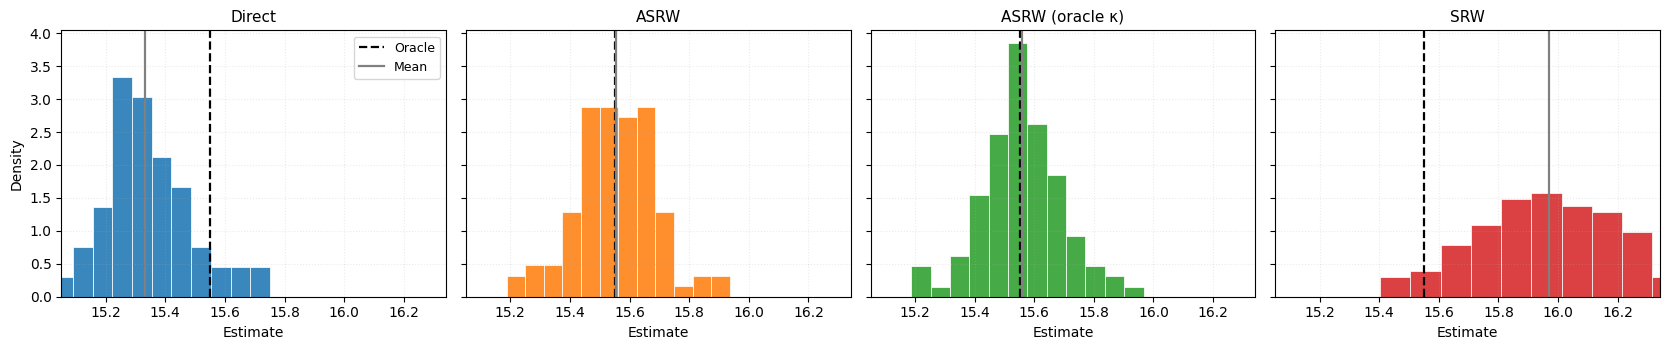

In [5]:
    out = run_simulation(
        R=100,
        N=20000,
        p=10,
        T=5,
        gamma=0.99,
        n_jobs=-1,
        n_splits_cf=5,
        q_arch="linear_a",
        direct_mode="linear_a",
        kappa_fit_method="variational",
        kappa_arch="linear_a",
        grad_penalty_kappa=0.0,
        n_epochs_q=150,
        n_epochs_kappa=150,
        make_plots=True,
        verbose=True,
    )